<a href="https://colab.research.google.com/github/annas05shariff/ML-LAB/blob/main/Logreg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

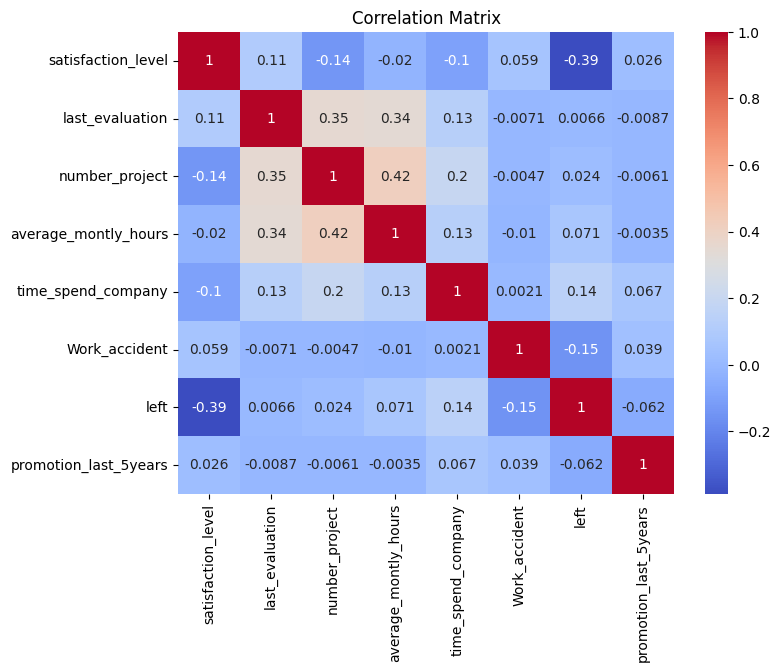

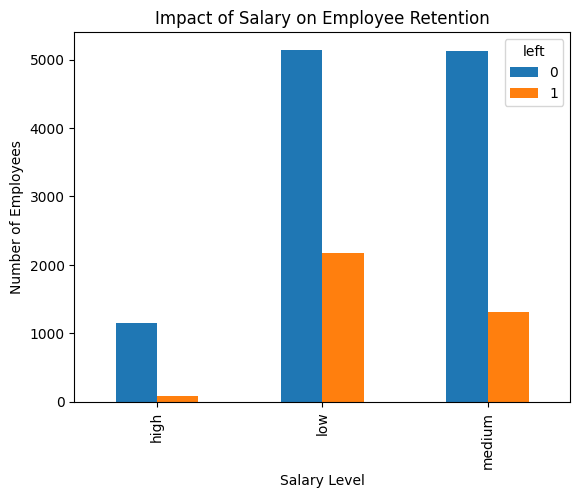

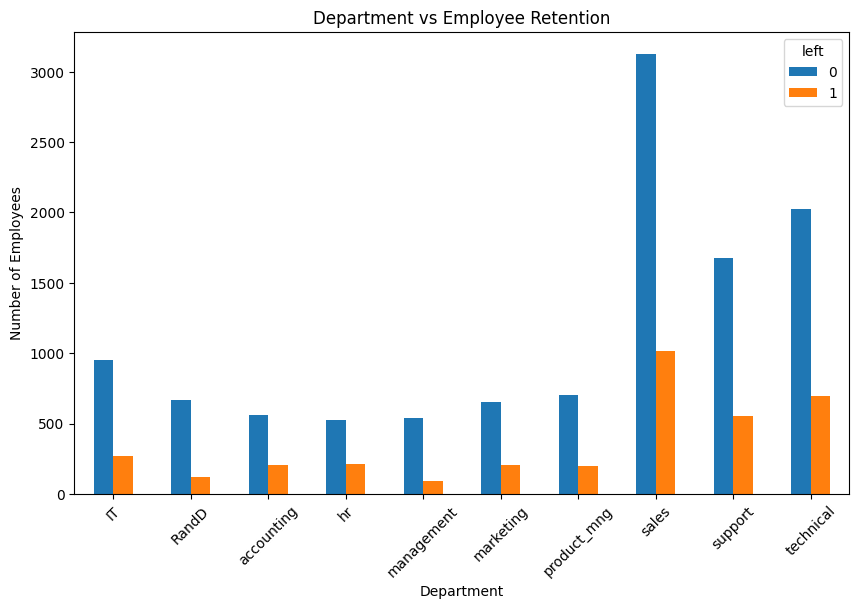

Model Accuracy: 0.7686666666666667


In [3]:
# ==============================
# 1. Import Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


# ==============================
# 2. Load Dataset
# ==============================

df = pd.read_csv("HR_comma_sep.csv")

print(df.head())
print(df.info())
print(df['left'].value_counts())


# ==============================
# 3. Exploratory Data Analysis
# ==============================

# A. Correlation Heatmap (for numerical variables)
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


# B. Salary vs Retention
salary_retention = pd.crosstab(df['salary'], df['left'])
salary_retention.plot(kind='bar')

plt.title("Impact of Salary on Employee Retention")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.show()


# C. Department vs Retention
dept_retention = pd.crosstab(df['Department'], df['left'])
dept_retention.plot(kind='bar', figsize=(10,6))

plt.title("Department vs Employee Retention")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.show()


# ==============================
# 4. Feature Selection (Based on EDA)
# ==============================

# From EDA typically these impact retention strongly:
# satisfaction_level
# average_montly_hours
# promotion_last_5years
# salary

# Convert salary into numeric (ordinal encoding)
df['salary'] = df['salary'].map({'low':0, 'medium':1, 'high':2})


# Select features
X = df[['satisfaction_level',
        'average_montly_hours',
        'promotion_last_5years',
        'salary']]

y = df['left']


# ==============================
# 5. Train Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


# ==============================
# 6. Feature Scaling
# ==============================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==============================
# 7. Logistic Regression Model
# ==============================

model = LogisticRegression()
model.fit(X_train_scaled, y_train)


# ==============================
# 8. Predictions & Accuracy
# ==============================

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)


  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  
1           1  
2           4  
3   

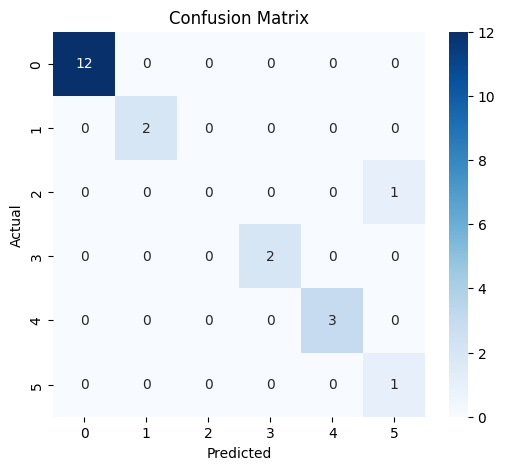

In [6]:
# =====================================
# 1. Import Libraries
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler


# =====================================
# 2. Load Dataset
# =====================================

# Zoo dataset
zoo = pd.read_csv("zoo-data.csv")

# Class type details (optional – for understanding classes)
class_type = pd.read_csv("zoo-class-type.csv")

print(zoo.head())
print(zoo.info())


# =====================================
# 3. Data Preprocessing
# =====================================

# Drop animal name column (not useful for prediction)
zoo = zoo.drop('animal_name', axis=1)

# Check missing values
print(zoo.isnull().sum())

# Separate features and target
X = zoo.drop('class_type', axis=1)
y = zoo['class_type']

# Most features are binary (0/1)
# Only 'legs' has different numeric values → scale it

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =====================================
# 4. Train Test Split
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)


# =====================================
# 5. Logistic Regression Model
# =====================================

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


# =====================================
# 6. Prediction & Accuracy
# =====================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)


# =====================================
# 7. Confusion Matrix
# =====================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model Accuracy: 0.7683333333333333


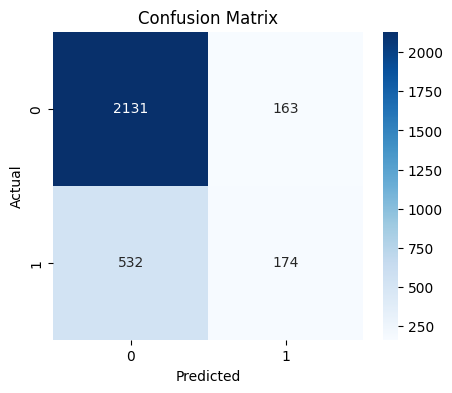

In [7]:
# ==========================================
# 1. Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix


# ==========================================
# 2. Load Dataset
# ==========================================

df = pd.read_csv("HR_comma_sep.csv")

# ==========================================
# 3. Preprocessing
# ==========================================

# Convert salary to numeric (ordinal)
df['salary'] = df['salary'].map({'low':0, 'medium':1, 'high':2})

# One-hot encode Department
df = pd.get_dummies(df, columns=['Department'], drop_first=True)

# Features and Target
X = df.drop('left', axis=1).values
y = df['left'].values

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


# ==========================================
# 4. Manual Logistic Regression
# ==========================================

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Initialize parameters
n_features = X_train.shape[1]
weights = np.zeros(n_features)
bias = 0

learning_rate = 0.01
epochs = 1000
m = len(y_train)

# Gradient Descent
for _ in range(epochs):

    linear_model = np.dot(X_train, weights) + bias
    y_pred = sigmoid(linear_model)

    # Gradients
    dw = (1/m) * np.dot(X_train.T, (y_pred - y_train))
    db = (1/m) * np.sum(y_pred - y_train)

    # Update
    weights -= learning_rate * dw
    bias -= learning_rate * db


# ==========================================
# 5. Prediction
# ==========================================

def predict(X):
    linear_model = np.dot(X, weights) + bias
    y_pred = sigmoid(linear_model)
    return [1 if i > 0.5 else 0 for i in y_pred]

y_pred_test = predict(X_test)


# ==========================================
# 6. Accuracy
# ==========================================

accuracy = np.mean(y_pred_test == y_test)
print("Model Accuracy:", accuracy)


# ==========================================
# 7. Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()